## Computational Astrobiology – Project Exploration

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import h5py

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"])
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.limits'] = (0, 0)
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

sol_mass = 1.989e33
sol_lum = 3.828e33
sol_r = 6.957e10

In [2]:
grid_file = 'PSLS/grid.hdf5'

def read_data(obj, field):
    if isinstance(obj, h5py.Dataset):
        return obj[field]
    else:
        return obj[field][:]

In [3]:
with h5py.File(grid_file, 'r') as f:
    print(f'--> found {len(f.keys())} keys in \'{grid_file}\':\n')
    for key in f.keys():
        print(f'{key}', end='\t')
    print('\n')

--> found 98 keys in 'PSLS/grid.hdf5':

grid_v0.1_ov0_001000	grid_v0.1_ov0_001002	grid_v0.1_ov0_001003	grid_v0.1_ov0_001006	grid_v0.1_ov0_001007	grid_v0.1_ov0_001008	grid_v0.1_ov0_001010	grid_v0.1_ov0_001012	grid_v0.1_ov0_001013	grid_v0.1_ov0_001014	grid_v0.1_ov0_001015	grid_v0.1_ov0_001018	grid_v0.1_ov0_001020	grid_v0.1_ov0_001021	grid_v0.1_ov0_001024	grid_v0.1_ov0_001025	grid_v0.1_ov0_001026	grid_v0.1_ov0_001027	grid_v0.1_ov0_001028	grid_v0.1_ov0_001030	grid_v0.1_ov0_001032	grid_v0.1_ov0_001034	grid_v0.1_ov0_001036	grid_v0.1_ov0_001037	grid_v0.1_ov0_001038	grid_v0.1_ov0_001040	grid_v0.1_ov0_001041	grid_v0.1_ov0_001042	grid_v0.1_ov0_001043	grid_v0.1_ov0_001044	grid_v0.1_ov0_001046	grid_v0.1_ov0_001048	grid_v0.1_ov0_001049	grid_v0.1_ov0_001051	grid_v0.1_ov0_001052	grid_v0.1_ov0_001054	grid_v0.1_ov0_001055	grid_v0.1_ov0_001056	grid_v0.1_ov0_001058	grid_v0.1_ov0_001060	grid_v0.1_ov0_001061	grid_v0.1_ov0_001062	grid_v0.1_ov0_001063	grid_v0.1_ov0_001064	grid_v0.1_ov0_001066	grid_v0.1_ov0_0

In [4]:
sub_level = 'grid_v0.1_ov0_001073'

with h5py.File(grid_file, 'r') as f:
    print(f'--> found {len(f[sub_level].keys())} keys in \'{sub_level}\':\n')
    for key in f[sub_level].keys():
        print(f'{key}', end='\t')
    print('\n')

--> found 5 keys in 'grid_v0.1_ov0_001073':

flags	global	input	osc	parameters	



In [5]:
subsub_levels = ['flags', 'global', 'input', 'osc']

with h5py.File(grid_file, 'r') as f:
    for subsub_level in subsub_levels:
        print(f'--> found {len(f[sub_level][subsub_level].keys())} keys in \'{subsub_level}\':\n')
        for key in f[sub_level][subsub_level].keys():
            print(f'{key}', end='\t')
        print('\n')

--> found 6 keys in 'flags':

lmax	lmin	ncz	nmax	nmin	tcz_he	

--> found 27 keys in 'global':

Xc	Y0	Z0	age	alpha	delta_nu	feh0	fehs	logg	lum	mass	mcz_core	mcz_env	numax	ovshts	radius	rcz_core	rcz_env	rhoav	rhoc	tcz_bcz	tcz_he	tcz_tot	teff	ys	z3s	zs	

--> found 8 keys in 'input':

adipls	adipls_redistrib	don	evol_code	evol_revision	osc_code	osc_revision	run	

--> found 1927 keys in 'osc':

0	1	10	100	1000	1001	1002	1003	1004	1005	1006	1007	1008	1009	101	1010	1011	1012	1013	1014	1015	1016	1017	1018	1019	102	1020	1021	1022	1023	1024	1025	1026	1027	1028	1029	103	1030	1031	1032	1033	1034	1035	1036	1037	1038	1039	104	1040	1041	1042	1043	1044	1045	1046	1047	1048	1049	105	1050	1051	1052	1053	1054	1055	1056	1057	1058	1059	106	1060	1061	1062	1063	1064	1065	1066	1067	1068	1069	107	1070	1071	1072	1073	1074	1075	1076	1077	1078	1079	108	1080	1081	1082	1083	1084	1085	1086	1087	1088	1089	109	1090	1091	1092	1093	1094	1095	1096	1097	1098	1099	11	110	1100	1101	1102	1103	1104	1105	1106	1107	1108	1109	111

plotting 'grid_v0.1_ov0_001073/global' parameters:



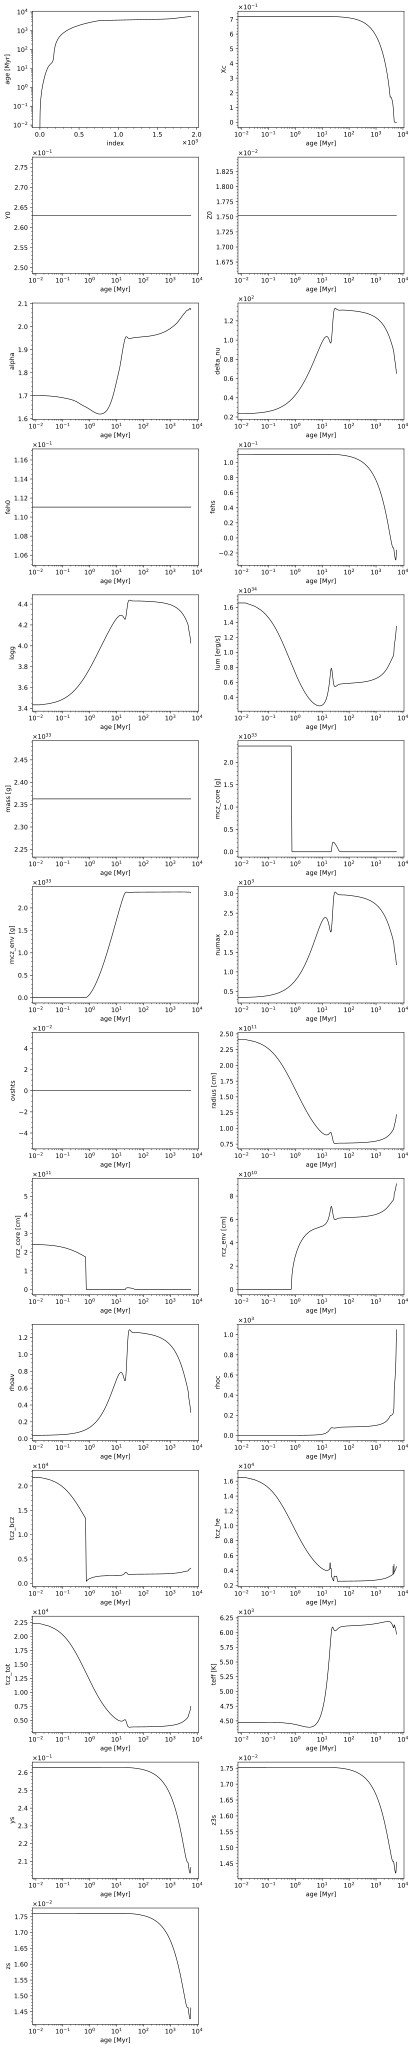

In [6]:
with h5py.File(grid_file) as f:
    age = read_data(f[sub_level][subsub_levels[1]], 'age')
    keys = [k for k in f[sub_level][subsub_levels[1]].keys() if k not in ['age']]
    fig, axs = plt.subplots(int(len(keys) / 2) + 1, 2, figsize=(9, 45))
    ax = axs.flatten()
    ax[0].plot(np.arange(len(age)), age, 'k-', lw=0.9)
    ax[0].set_yscale('log')
    ax[0].set_xlabel('index')
    ax[0].set_ylabel('age [Myr]')    
    ax[-1].set_axis_off()
    i = 0
    for key in keys:
        i += 1
        ax[i].plot(age, read_data(f[sub_level][subsub_levels[1]], key), 'k-', lw=0.9)
        ax[i].set_xscale('log')
        ax[i].set_xlabel('age [Myr]')
        match key:
            case 'lum':
                unit = ' [erg/s]'
            case 'mass' | 'mcz_core' | 'mcz_env':
                unit = ' [g]'
            case 'radius' | 'rcz_core' | 'rcz_env':
                unit = ' [cm]'
            case 'teff':
                unit = ' [K]'
            case _:
                unit = ''
        ax[i].set_ylabel(f'{key}{unit}')
    print(f'plotting \'{sub_level}/{subsub_levels[1]}\' parameters:\n')
    plt.show()
    plt.close()

track                │ mass  │ teff        │ logg       
─────────────────────┼───────┼─────────────┼────────────
grid_v0.1_ov0_001000 │ 1.050 │ 4323 – 5940 │ 3.44 – 4.51
grid_v0.1_ov0_001002 │ 0.975 │ 4306 – 5903 │ 3.45 – 4.53
grid_v0.1_ov0_001003 │ 1.012 │ 4216 – 5866 │ 3.42 – 4.54
grid_v0.1_ov0_001006 │ 0.937 │ 4041 – 5639 │ 3.40 – 4.57
grid_v0.1_ov0_001007 │ 0.956 │ 4208 – 5839 │ 3.44 – 4.57
grid_v0.1_ov0_001008 │ 1.106 │ 4344 – 6121 │ 3.42 – 4.46
grid_v0.1_ov0_001010 │ 1.031 │ 4420 – 6184 │ 3.46 – 4.50
grid_v0.1_ov0_001012 │ 1.143 │ 4487 – 6338 │ 3.45 – 4.43
grid_v0.1_ov0_001013 │ 1.068 │ 4429 – 6194 │ 3.46 – 4.49
grid_v0.1_ov0_001014 │ 0.918 │ 4104 – 5743 │ 3.41 – 4.57
grid_v0.1_ov0_001015 │ 0.928 │ 4016 – 5592 │ 3.40 – 4.58
grid_v0.1_ov0_001018 │ 1.003 │ 4249 – 5939 │ 3.43 – 4.53
grid_v0.1_ov0_001020 │ 1.190 │ 4382 – 6191 │ 3.42 – 4.43
grid_v0.1_ov0_001021 │ 1.115 │ 4335 – 5971 │ 3.43 – 4.48
grid_v0.1_ov0_001024 │ 1.097 │ 4528 – 6385 │ 3.47 – 4.45
grid_v0.1_ov0_001025 │ 1.172 │ 

(array([[   0.,    0.,    0.,    0.,    0.,  220.,    0.,    0.,    0.,
            0.],
        [   0.,    0.,  210.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [   0.,    0.,    0., 1228.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [   0., 1288.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [   0., 1190.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [   0.,    0.,    0.,    0.,    0.,    0., 1048.,    0.,    0.,
            0.],
        [   0.,    0.,    0.,    0.,  978.,    0.,    0.,    0.,    0.,
            0.],
        [   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,  969.,
            0.],
        [   0.,    0.,    0.,    0.,    0., 1024.,    0.,    0.,    0.,
            0.],
        [1118.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [1276.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.],
        [   0.,    0.

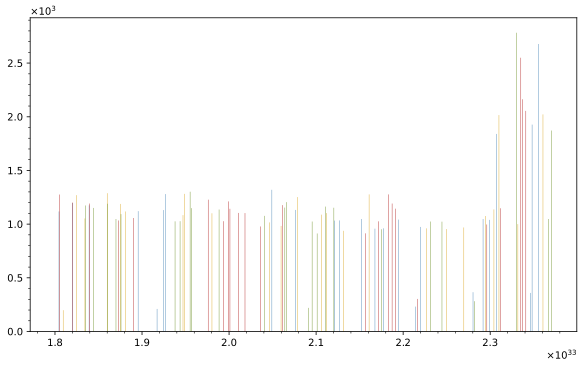

In [43]:
from collections import defaultdict

with h5py.File(grid_file) as f:
    params = defaultdict(list)
    params_max = defaultdict(list)
    params_min = defaultdict(list)
    for track in [k for k in f.keys() if k not in ['license']]:
        for key in f[track][subsub_levels[1]].keys():
            tmp_arr = read_data(f[track][subsub_levels[1]], key)
            params[key].append(tmp_arr)
            params_max[key].append(max(tmp_arr))
            params_min[key].append(min(tmp_arr))
    j = 0
    print('track                │ mass  │ teff        │ logg       ')
    print('─────────────────────┼───────┼─────────────┼────────────')
    for track in [k for k in f.keys() if k not in ['license']]:
        print(f'{track} │ {params_min['mass'][j] / sol_mass:.3f} │ {params_min['teff'][j]:.0f} – {params_max['teff'][j]:.0f} │ {params_min['logg'][j]:.2f} – {params_max['logg'][j]:.2f}')
        j += 1

plt.hist(params['mass'], bins=10)